In [12]:
# Package imports
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
DATA_FILES = {
    "fb_pec_blindagem": '../data/fb_10092025_31102025_pec_blindagem.csv',
    "ig_pec_blindagem": '../data/ig_10092025_31102025_pec_blindagem.csv'
}

In [21]:
df = pd.read_csv(DATA_FILES.get("fb_pec_blindagem"))
df_ig = pd.read_csv(DATA_FILES.get("ig_pec_blindagem"))

# print(df.shape)
# print(df.columns.tolist())
# df.head()

In [22]:
# --- 2. COMPLETUDE ---
nulos = df.isnull().sum()
percentual = (nulos / len(df) * 100).round(2)

completude = pd.DataFrame({
    'nulos': nulos,
    'percentual_%': percentual
}).sort_values('percentual_%', ascending=False)

print(completude)

                                      nulos  percentual_%
activities                            16476        100.00
shared_post_id                        15918         96.61
link_attachment.description           13025         79.05
link_attachment.link                  12761         77.45
link_attachment.caption               12728         77.25
link_attachment.name                  12727         77.25
multimedia                             4224         25.64
statistics.views                       2971         18.03
statistics.views_date_last_refreshed   2971         18.03
surface.username                       1825         11.08
post_owner.username                    1150          6.98
statistics.love_count                   369          2.24
statistics.wow_count                    369          2.24
statistics.like_count                   369          2.24
statistics.haha_count                   369          2.24
statistics.sad_count                    369          2.24
statistics.car

In [24]:
# --- 2. COMPLETUDE ---
nulos = df_ig.isnull().sum()
percentual = (nulos / len(df_ig) * 100).round(2)

completude = pd.DataFrame({
    'nulos': nulos,
    'percentual_%': percentual
}).sort_values('percentual_%', ascending=False)

print(completude)

                                      nulos  percentual_%
hashtags                              10619         58.19
statistics.like_count                  1645          9.01
statistics.views                        218          1.19
statistics.views_date_last_refreshed    218          1.19
statistics.comment_count                 48          0.26
post_owner.name                          46          0.25
lang                                     43          0.24
text                                     24          0.13
modified_time                            24          0.13
multimedia                                1          0.01
content_type                              0          0.00
creation_time                             0          0.00
post_owner.id                             0          0.00
is_branded_content                        0          0.00
match_type                                0          0.00
id                                        0          0.00
mcl_url       

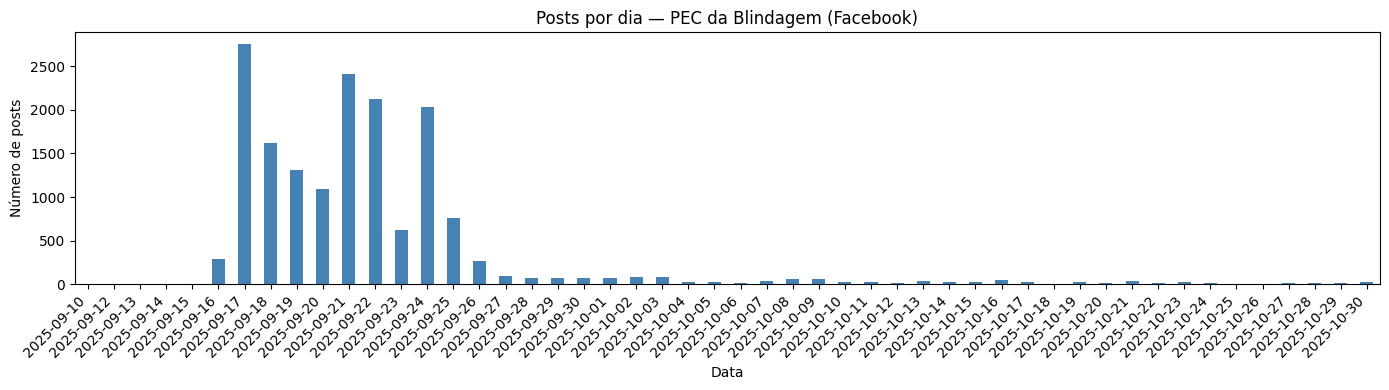

In [13]:
# --- 3. DISTRIBUIÇÃO TEMPORAL ---
df['creation_time'] = pd.to_datetime(df['creation_time'])

posts_por_dia = df.groupby(df['creation_time'].dt.date).size()

plt.figure(figsize=(14, 4))
posts_por_dia.plot(kind='bar', color='steelblue')
plt.title('Posts por dia — PEC da Blindagem (Facebook)')
plt.xlabel('Data')
plt.ylabel('Número de posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

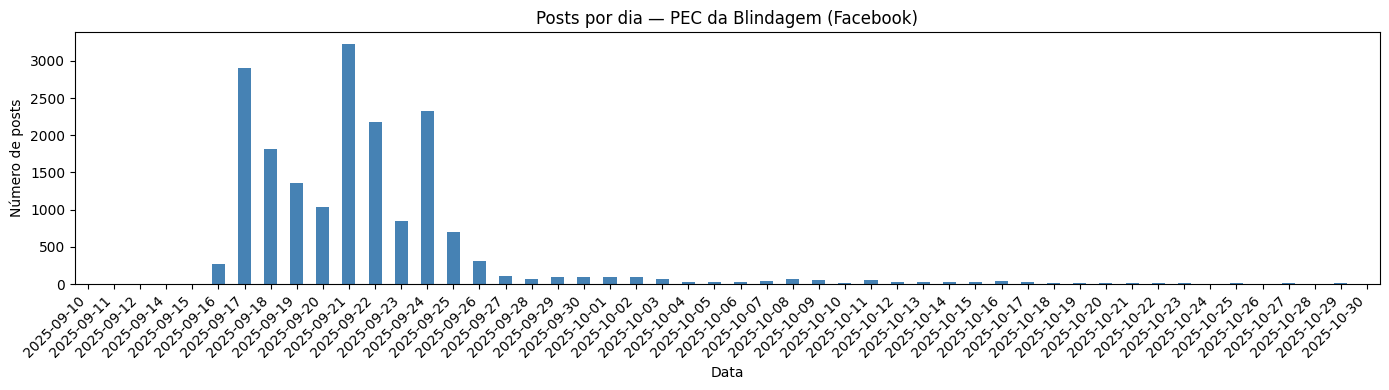

In [25]:
# --- 3. DISTRIBUIÇÃO TEMPORAL ---
df_ig['creation_time'] = pd.to_datetime(df_ig['creation_time'])

posts_por_dia = df_ig.groupby(df_ig['creation_time'].dt.date).size()

plt.figure(figsize=(14, 4))
posts_por_dia.plot(kind='bar', color='steelblue')
plt.title('Posts por dia — PEC da Blindagem (Facebook)')
plt.xlabel('Data')
plt.ylabel('Número de posts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# --- 4. TIPOS DE CONTEÚDO ---
print(df['content_type'].value_counts())

content_type
photos     6122
videos     4749
links      3712
albums      868
reshare     542
status      424
Name: count, dtype: int64


In [15]:
# --- 5. TIPOS DE AUTOR ---
print(df['post_owner.type'].value_counts())

post_owner.type
page       14477
profile     1999
Name: count, dtype: int64


In [16]:
# --- 6. ENGAJAMENTO GERAL ---
colunas_engajamento = [
    'statistics.like_count',
    'statistics.love_count',
    'statistics.angry_count',
    'statistics.haha_count',
    'statistics.sad_count',
    'statistics.wow_count',
    'statistics.care_count',
    'statistics.comment_count',
    'statistics.share_count',
    'statistics.reaction_count'
]

print(df[colunas_engajamento].describe().round(2))

       statistics.like_count  statistics.love_count  statistics.angry_count  \
count               16107.00               16107.00                16107.00   
mean                  460.26                  50.13                   15.37   
std                  3532.73                 432.77                  179.67   
min                     0.00                   0.00                    0.00   
25%                     3.00                   0.00                    0.00   
50%                    17.00                   1.00                    0.00   
75%                    92.00                   7.00                    3.00   
max                124452.00               22450.00                15855.00   

       statistics.haha_count  statistics.sad_count  statistics.wow_count  \
count               16107.00              16107.00              16107.00   
mean                   22.49                  1.23                  1.03   
std                   160.25                 16.32          

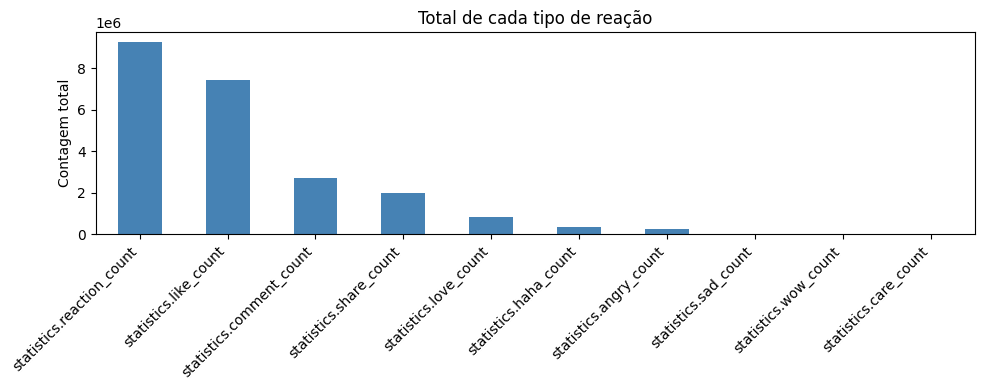

In [17]:
# --- 7. REAÇÕES AGREGADAS --- 
total_reacoes = df[colunas_engajamento].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
total_reacoes.plot(kind='bar', color='steelblue')
plt.title('Total de cada tipo de reação')
plt.ylabel('Contagem total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
# --- 8. IDIOMAS ---
print(df['lang'].value_counts())

lang
pt    16476
Name: count, dtype: int64


In [26]:
print(df['post_owner.type'].value_counts())
print()
print(f"Total de autores únicos: {df['post_owner.id'].nunique()}")
print()

# distribuição de posts por autor, ordenado pelos mais ativos
posts_por_autor = (
    df.groupby(['post_owner.id', 'post_owner.name', 'post_owner.type'])
    .size()
    .reset_index(name='total_posts')
    .sort_values('total_posts', ascending=False)
)

print("Top 20 autores mais ativos:")
print(posts_por_autor.head(20).to_string(index=False))

post_owner.type
page       14477
profile     1999
Name: count, dtype: int64

Total de autores únicos: 3805

Top 20 autores mais ativos:
   post_owner.id            post_owner.name post_owner.type  total_posts
1482507799217722                  CNNBrasil            page          156
 303077622362407 Brasil livre de Bolsonaro             page          144
1028469195320628   Stephanie Davi de Castro            page          129
1828159527652743         Suderlan De Castro            page          126
 763498368933613                  GloboNews            page          125
1441191107004238           CLT da Depressão            page          114
1365872967344938        Estado do Pará News            page          113
 331564629658139             Jovem Pan News            page          111
1469095197428757        Metrópoles Política            page          107
1093865492216716       Newdson Castro Silva         profile           92
 434527045887885       Aquarela Productions            page  

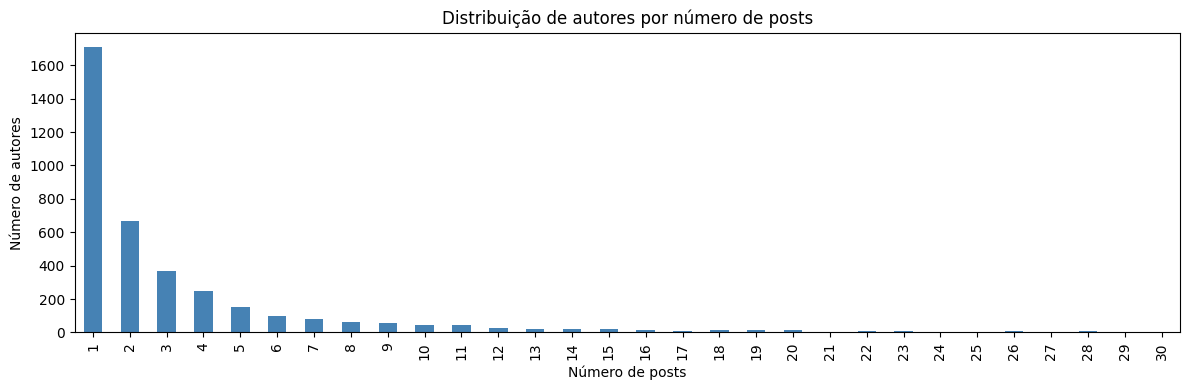

In [27]:
# distribuição de frequência — quantos autores postaram 1x, 2x, 3x etc
frequencia = posts_por_autor['total_posts'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
frequencia.head(30).plot(kind='bar', color='steelblue')
plt.title('Distribuição de autores por número de posts')
plt.xlabel('Número de posts')
plt.ylabel('Número de autores')
plt.tight_layout()
plt.show()

In [28]:
# separando páginas de perfis individuais
for tipo in df['post_owner.type'].unique():
    subset = posts_por_autor[posts_por_autor['post_owner.type'] == tipo]
    print(f"\n--- {tipo} ---")
    print(f"Total de autores: {len(subset)}")
    print(f"Total de posts: {subset['total_posts'].sum()}")
    print(f"Mediana de posts por autor: {subset['total_posts'].median()}")
    print(f"Máximo de posts por um autor: {subset['total_posts'].max()}")


--- page ---
Total de autores: 3306
Total de posts: 14477
Mediana de posts por autor: 2.0
Máximo de posts por um autor: 156

--- profile ---
Total de autores: 499
Total de posts: 1999
Mediana de posts por autor: 1.0
Máximo de posts por um autor: 92


In [32]:
print(df_ig['post_owner.type'].value_counts())
print()
print(f"Total de autores únicos: {df_ig['post_owner.id'].nunique()}")
print()

# distribuição de posts por autor, ordenado pelos mais ativos
posts_por_autor_ig = (
    df_ig.groupby(['post_owner.id', 'post_owner.name', 'post_owner.type'])
    .size()
    .reset_index(name='total_posts')
    .sort_values('total_posts', ascending=False)
)

print("Top 20 autores mais ativos:")
print(posts_por_autor_ig.head(20).to_string(index=False))

post_owner.type
creator     10937
business     7143
personal      169
Name: count, dtype: int64

Total de autores únicos: 5651

Top 20 autores mais ativos:
   post_owner.id                                   post_owner.name post_owner.type  total_posts
1367620613932947                               Politizando Alagoas        business          133
2207969159577032                               Metrópoles Política        business           75
1384590726224967                               Esquerda Brasil 4.0        business           73
2551132138386533                                         GloboNews         creator           72
6992210664203390                                 Politica Alagoana         creator           69
 883371226927404 Márcio Garrote - Seu boletim político atualizado.         creator           66
1688823528278850                                          Rede TVT        business           54
1041310223862227                                       Metrópoles         c

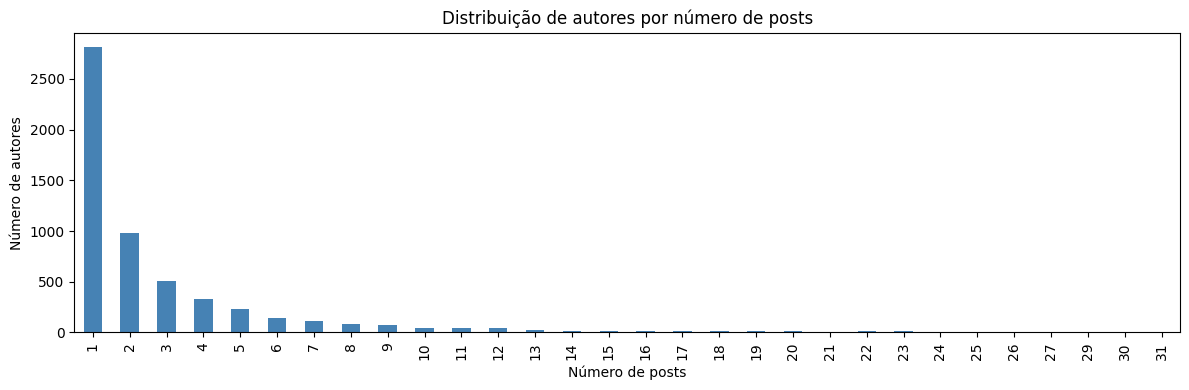

In [34]:
# distribuição de frequência — quantos autores postaram 1x, 2x, 3x etc
frequencia = posts_por_autor_ig['total_posts'].value_counts().sort_index()

plt.figure(figsize=(12, 4))
frequencia.head(30).plot(kind='bar', color='steelblue')
plt.title('Distribuição de autores por número de posts')
plt.xlabel('Número de posts')
plt.ylabel('Número de autores')
plt.tight_layout()
plt.show()

In [33]:
# separando páginas de perfis individuais
for tipo in df_ig['post_owner.type'].unique():
    subset = posts_por_autor[posts_por_autor_ig['post_owner.type'] == tipo]
    print(f"\n--- {tipo} ---")
    print(f"Total de autores: {len(subset)}")
    print(f"Total de posts: {subset['total_posts'].sum()}")
    print(f"Mediana de posts por autor: {subset['total_posts'].median()}")
    print(f"Máximo de posts por um autor: {subset['total_posts'].max()}")


--- creator ---
Total de autores: 3712
Total de posts: 10902
Mediana de posts por autor: 1.0
Máximo de posts por um autor: 72

--- business ---
Total de autores: 1840
Total de posts: 7134
Mediana de posts por autor: 2.0
Máximo de posts por um autor: 133

--- personal ---
Total de autores: 72
Total de posts: 167
Mediana de posts por autor: 1.0
Máximo de posts por um autor: 31
